# Visualising `weighted_cvt` layouts

Every case below shows the power-cell tessellation on the left and target-versus-actual
cell areas on the right, so the area error is visible rather than only printed.

1. Setup and the case catalogue
2. Plotting helpers
3. One case in detail
4. All cases as small multiples
5. Convergence of the outer loop
6. Dominated (empty) cells
7. Overlay against the `voronoip` library
8. Equal area weights versus a plain CVT
9. Interactive weight slider

Run top to bottom. Section 7 needs `voronoip` and section 9 needs `ipywidgets`; both
skip themselves politely when the package is missing.

In [10]:
%matplotlib inline

import sys
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from scipy.spatial import ConvexHull

ROOT = Path(r'c:\dev\csi_safe_automation')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import weighted_cvt as wcvt
from lloyd_cvt import lloyd_cvt

print('kernel      ', sys.executable)
print('numpy       ', np.__version__)
print('matplotlib  ', matplotlib.__version__)
print('module      ', wcvt.__file__)

kernel       c:\python314\python.exe
numpy        2.3.2
matplotlib   3.11.1
module       c:\dev\csi_safe_automation\weighted_cvt.py


In [11]:
RECT = [(0.0, 0.0), (3.0, 0.0), (3.0, 2.0), (0.0, 2.0)]

_angles = np.linspace(0.0, 2.0 * np.pi, 7)[:-1]
HEX = [(1.0 + np.cos(a), 1.5 + np.sin(a)) for a in _angles]

_rng = np.random.default_rng(11)
_points = _rng.uniform(0.0, 1.0, size=(14, 2))
RANDOM_CONVEX = [tuple(p) for p in _points[ConvexHull(_points).vertices]]

CASES = [
    {'name': 'equal weights', 'polygon': RECT, 'weights': [1.0] * 6, 'seed': None},
    {'name': 'mild spread', 'polygon': RECT,
     'weights': [1.0, 1.2, 1.5, 1.8, 2.0, 2.4], 'seed': 1},
    {'name': '15:1 spread', 'polygon': RECT,
     'weights': [0.2, 0.5, 1.0, 1.5, 2.0, 3.0], 'seed': 1},
    {'name': 'lopsided', 'polygon': RECT,
     'weights': [0.05, 1.0, 1.0, 1.0, 1.0, 6.0], 'seed': 1},
    {'name': 'hexagon', 'polygon': HEX,
     'weights': [1.0, 1.0, 2.0, 2.0, 3.0, 4.0], 'seed': 2},
    {'name': 'random convex, 12 sites', 'polygon': RANDOM_CONVEX,
     'weights': [1.0] * 12, 'seed': 3},
]

for case in CASES:
    name = case['name']
    count = len(case['weights'])
    print(f'{name:24} {count:3d} sites')

equal weights              6 sites
mild spread                6 sites
15:1 spread                6 sites
lopsided                   6 sites
hexagon                    6 sites
random convex, 12 sites   12 sites


## Plotting helpers

`draw_cells` fills the power cells, outlines the polygon, marks the sites and prints each
cell's area at its middle. It re-derives the cells with `power_cells`, so the picture is
what the library actually produced rather than a redraw. An empty cell has no polygon,
so its site is marked with a cross instead.

In [12]:
def area_of(ring):
    """Shoelace area of a polygon ring."""
    x = ring[:, 0]
    y = ring[:, 1]
    return abs(0.5 * float(np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)))


def draw_cells_raw(ax, polygon, sites, cells, areas=None, show_areas=True):
    """Fill already-computed power `cells`, outline the polygon, mark the sites.

    An empty cell has no polygon to fill, so its site gets a cross instead.
    """
    poly = np.asarray(polygon, dtype=float)
    colours = matplotlib.colormaps['tab20'](np.linspace(0.0, 1.0, len(cells)))
    for i, cell in enumerate(cells):
        if len(cell) >= 3:
            ax.add_patch(MplPolygon(cell, closed=True, facecolor=colours[i],
                                    edgecolor='black', linewidth=0.8, alpha=0.7))
            if show_areas and areas is not None:
                cx, cy = cell.mean(axis=0)
                ax.text(cx, cy, f'{areas[i]:.2f}',
                        ha='center', va='center', fontsize=7)
        else:
            x, y = sites[i]
            ax.plot(x, y, marker='x', color='crimson', markersize=11,
                    markeredgewidth=2.5, linestyle='none')
    ax.add_patch(MplPolygon(poly, closed=True, fill=False,
                            edgecolor='navy', linewidth=2.5))
    xs = [p[0] for p in sites]
    ys = [p[1] for p in sites]
    ax.plot(xs, ys, marker='o', linestyle='none', color='white',
            markeredgecolor='black', markersize=6, zorder=6)
    for i, (x, y) in enumerate(sites):
        ax.annotate(str(i), (x, y), textcoords='offset points',
                    xytext=(6, 4), fontsize=8)
    lo = poly.min(axis=0)
    hi = poly.max(axis=0)
    pad = 0.06 * float(np.hypot(*(hi - lo)))
    ax.set_xlim(lo[0] - pad, hi[0] + pad)
    ax.set_ylim(lo[1] - pad, hi[1] + pad)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])


def draw_cells(ax, polygon, result, show_areas=True):
    """Fill the cells of a `WeightedCVT` result, re-derived from the library."""
    cells = wcvt.power_cells(polygon, result.sites, result.weights)
    draw_cells_raw(ax, polygon, result.sites, cells, result.areas, show_areas)


def draw_bars(ax, result):
    """Target against actual area, one pair of bars per site."""
    n = len(result.areas)
    y = np.arange(n)
    actual = np.asarray(result.areas, dtype=float)
    target = np.asarray(result.targets, dtype=float)
    total = target.sum()
    over = (np.abs(actual - target) / total) > 1e-3
    ax.barh(y, target, height=0.72, color='0.8', label='target')
    ax.barh(y, actual, height=0.38,
            color=np.where(over, 'crimson', 'seagreen'), label='actual')
    ax.set_yticks(y)
    ax.set_yticklabels([str(i) for i in range(n)])
    ax.invert_yaxis()
    ax.set_xlabel('cell area')
    ax.set_title(f'max area error {result.max_area_error:.2e}    '
                 f'{result.iterations} iters    converged={result.converged}',
                 fontsize=9)
    ax.legend(loc='lower right', fontsize=8)


def plot_case(polygon, weights, seed=None, title=None):
    """One row: cells on the left, areas on the right."""
    result = wcvt.weighted_cvt(polygon, weights, seed=seed)
    fig, (ax_cells, ax_bars) = plt.subplots(
        1, 2, figsize=(10.5, 3.7), gridspec_kw={'width_ratios': [1.35, 1.0]}
    )
    draw_cells(ax_cells, polygon, result)
    draw_bars(ax_bars, result)
    if title is None:
        title = f'{len(weights)} sites'
    ax_cells.set_title(title, loc='left', fontsize=10)
    fig.tight_layout()
    return result, fig


print('helpers ready')

helpers ready


## One case in detail

Weights 1/1/2/2/3/5 on the rectangle. The bar chart is the check that matters: grey is
the area the weights asked for, colour is what came out, and a bar that misses by more
than `area_tol` is drawn red.

max area error 0.0004949109690504383
iterations     200
validate       clean


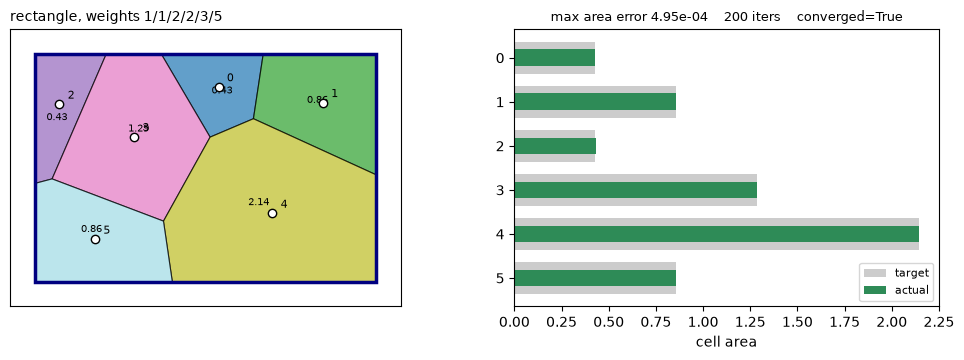

In [13]:
result, fig = plot_case(
    RECT, [1.0, 1.0, 2.0, 2.0, 3.0, 5.0], seed=1,
    title='rectangle, weights 1/1/2/2/3/5',
)
print('max area error', result.max_area_error)
print('iterations    ', result.iterations)
problems = wcvt.validate_weighted(RECT, result.sites, result.weights, result.targets)
print('validate      ', problems or 'clean')

## All cases as small multiples

One row per case. Reading down the right-hand column shows how the area error behaves as
the weights get more uneven and the polygon less regular.

One row is worth pausing on. The lopsided row does not converge (`converged=False`): with
one weight 250 times another, the solver collapses the light cells to zero area, drawn as
crosses, instead of spreading the rest of the area over them. The next section looks at
empty cells directly.

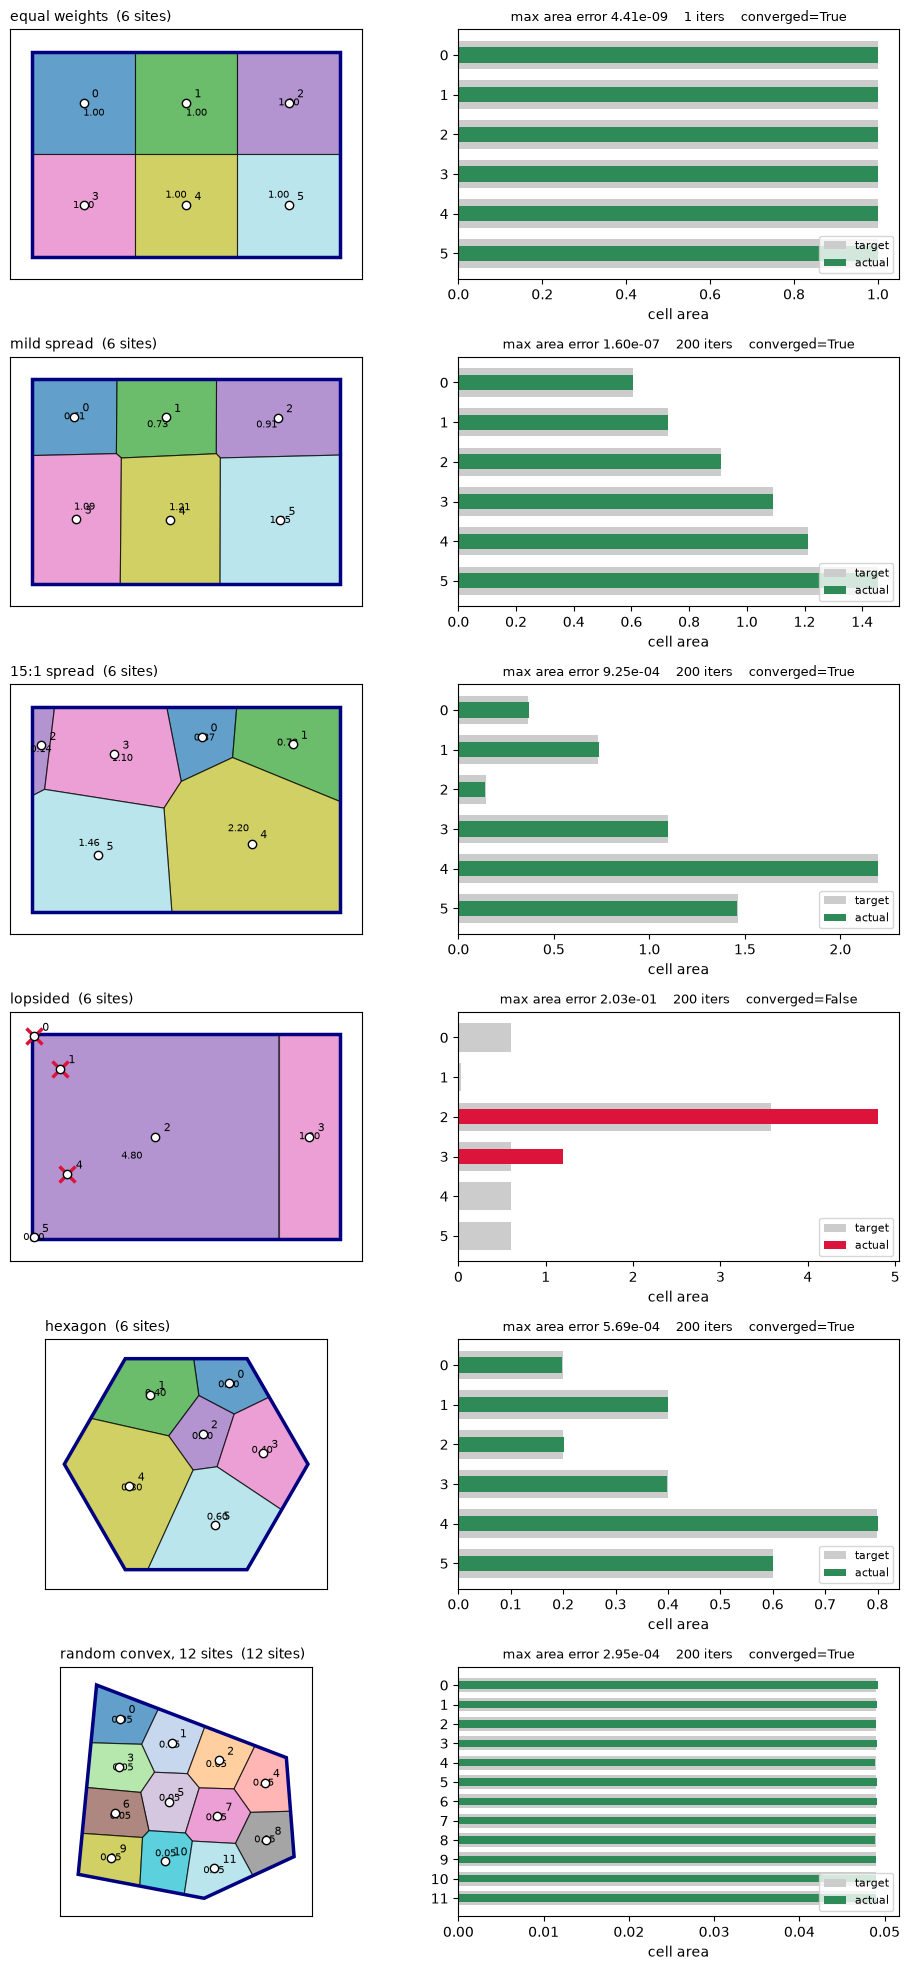

In [14]:
rows = len(CASES)
fig, axes = plt.subplots(rows, 2, figsize=(10.5, 3.3 * rows),
                         gridspec_kw={'width_ratios': [1.35, 1.0]})
for row, case in enumerate(CASES):
    result = wcvt.weighted_cvt(case['polygon'], case['weights'], seed=case['seed'])
    draw_cells(axes[row][0], case['polygon'], result)
    draw_bars(axes[row][1], result)
    name = case['name']
    count = len(case['weights'])
    axes[row][0].set_title(f'{name}  ({count} sites)', loc='left', fontsize=10)
fig.tight_layout()

## Convergence of the outer loop

`weighted_cvt` does not return its history, so this re-runs the outer loop out of the
module's own pieces to record it: the alternating weight solve and damped site move, with
the area error and the site movement logged each step.

first iteration with the error at or under area_tol: 1
most empty cells seen during the run: 0


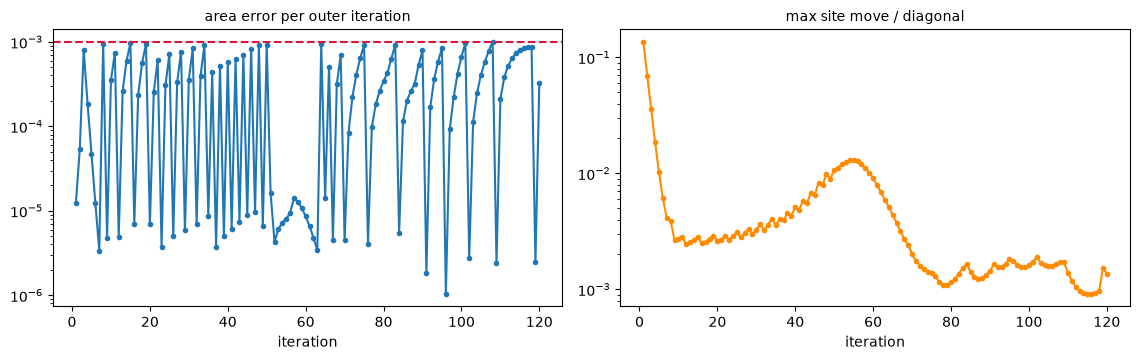

In [15]:
from lloyd_cvt import _area, _centroid, _ring
from weighted_cvt import _solve_weights


def convergence_trace(polygon, weights, seed=None, damping=0.5, max_iter=120,
                      weight_iter=50, mode='auto', area_tol=1e-3):
    """Re-run the outer loop, recording the area error and site move each step."""
    poly, poly_area2 = _ring(polygon)
    total = poly_area2 / 2.0
    diag = float(np.hypot(*np.ptp(poly, axis=0)))
    w = np.asarray(weights, dtype=float)
    targets = total * w / w.sum()
    sites = np.asarray(lloyd_cvt(poly, len(w), seed=seed), dtype=float).reshape(len(w), 2)
    lam = np.zeros(len(w))
    errors, moves, empty = [], [], []
    for _ in range(max_iter):
        lam, cells, areas = _solve_weights(poly, sites, lam, targets, area_tol,
                                           weight_iter, mode)
        errors.append(float(np.abs(areas - targets).max() / total))
        shifted = sites.copy()
        for i, cell in enumerate(cells):
            if _area(cell) > 1e-12 * total:
                shifted[i] = _centroid(cell, sites[i])
        delta = shifted - sites
        moves.append(float(np.hypot(*delta.T).max()) / diag)
        empty.append(len(cells) - sum(1 for cell in cells if len(cell) >= 3))
        sites = sites + damping * delta
    return np.array(errors), np.array(moves), np.array(empty)


errors, moves, empty = convergence_trace(RECT, [1.0, 1.0, 2.0, 2.0, 3.0, 5.0], seed=1)

fig, (ax_err, ax_move) = plt.subplots(1, 2, figsize=(11.5, 3.7))
steps = np.arange(1, len(errors) + 1)
ax_err.semilogy(steps, errors, marker='o', markersize=3)
ax_err.axhline(1e-3, color='crimson', linestyle='--')
ax_err.set_title('area error per outer iteration', fontsize=10)
ax_err.set_xlabel('iteration')
ax_move.semilogy(steps, moves, marker='o', markersize=3, color='darkorange')
ax_move.set_title('max site move / diagonal', fontsize=10)
ax_move.set_xlabel('iteration')
fig.tight_layout()

above = np.flatnonzero(errors > 1e-3)
first_ok = int(above[-1]) + 2 if above.size else 1
print('first iteration with the error at or under area_tol:', first_ok)
print('most empty cells seen during the run:', int(empty.max()))

## Dominated (empty) cells

A power cell can vanish outright. The Laguerre weights here are set by hand rather than
solved, so the outcome is deliberate rather than a stalled search: five evenly spaced
sites with a large weight on the middle one. Its cell swells until the two sites either
side of it have nowhere left to be, and their areas go to exactly zero.

An empty cell has no polygon to fill, so its site is drawn with a cross. Every surviving
site sits inside its own cell — which a power diagram does not generally guarantee once
the weights get lopsided.

sites      5
non-empty  3
empty      2
areas      [1.2 0.  3.6 0.  1.2]


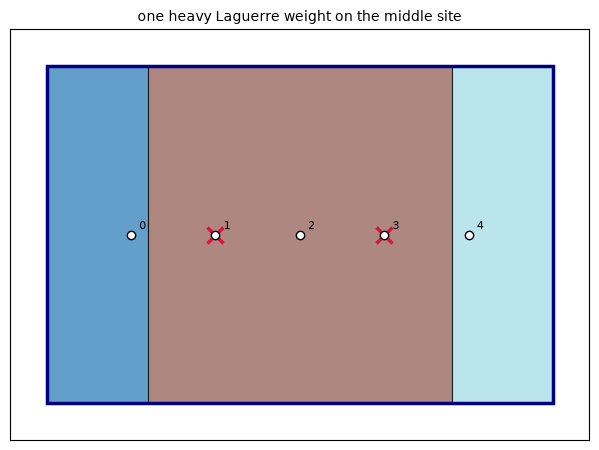

In [21]:
# Laguerre weights set by hand rather than solved, so the empty cells are deliberate.
# Five evenly spaced sites, a large weight on the middle one: its cell swells until the
# two sites either side have nowhere left to be.
row_sites = np.array([[0.5, 1.0], [1.0, 1.0], [1.5, 1.0], [2.0, 1.0], [2.5, 1.0]])
laguerre = np.array([0.0, 0.0, 0.8, 0.0, 0.0])
cells = wcvt.power_cells(RECT, row_sites, laguerre)
areas = np.array([area_of(c) if len(c) >= 3 else 0.0 for c in cells])

fig, ax = plt.subplots(figsize=(6.8, 4.6))
# No area labels here: the middle cell's centroid is its own site, so a label would sit
# on the marker. The printed areas below carry the numbers instead.
draw_cells_raw(ax, RECT, row_sites, cells, show_areas=False)
ax.set_title('one heavy Laguerre weight on the middle site', fontsize=10)
fig.tight_layout()

non_empty = sum(1 for a in areas if a > 1e-12)
print('sites     ', len(areas))
print('non-empty ', non_empty)
print('empty     ', len(areas) - non_empty)
print('areas     ', np.round(areas, 4))

## Overlay against `voronoip`

`voronoip` builds the same power cells with an independent engine
(`HalfspaceIntersection` plus a Chebyshev-centre LP). Its weights are radii, so this
passes `sqrt(lam - min(lam))` - a gauge shift, which leaves the diagram unchanged but
makes every radius real. Its cell boundaries are the dashed red lines, and the number
printed underneath says how far the two area sets are apart.

max |my area - voronoip area| = 4.440892098500626e-16


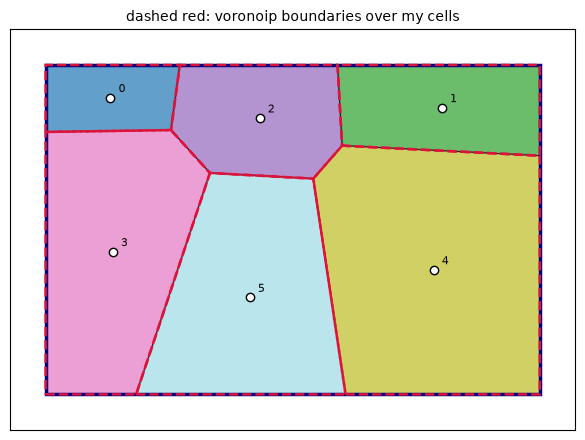

In [17]:
try:
    from voronoip import Voronoi as VoronoipVoronoi
    HAVE_VORONOIP = True
except ImportError:
    HAVE_VORONOIP = False

if not HAVE_VORONOIP:
    print('voronoip is not installed in this kernel - skipping the overlay')
else:
    result = wcvt.weighted_cvt(RECT, [0.5, 1.0, 1.0, 2.0, 2.0, 3.0], seed=1)
    lam = np.asarray(result.weights, dtype=float)
    radii = np.sqrt(lam - lam.min())
    theirs = VoronoipVoronoi(np.asarray(result.sites), mode='power',
                             radii=radii, bbox=[0.0, 0.0, 3.0, 2.0]).polygons
    their_areas = np.array([area_of(np.asarray(c, dtype=float)) for c in theirs])

    fig, ax = plt.subplots(figsize=(6.6, 4.5))
    draw_cells(ax, RECT, result, show_areas=False)
    for cell in theirs:
        cell = np.asarray(cell, dtype=float)
        if len(cell) >= 3:
            ax.add_patch(MplPolygon(cell, closed=True, fill=False,
                                    edgecolor='crimson', linewidth=1.8,
                                    linestyle='--', zorder=7))
    ax.set_title('dashed red: voronoip boundaries over my cells', fontsize=10)
    fig.tight_layout()
    worst = float(np.abs(their_areas - np.asarray(result.areas)).max())
    print('max |my area - voronoip area| =', worst)

## Equal area weights versus a plain CVT

Worth seeing once: asking for equal areas is a stricter condition than a centroidal
Voronoi tessellation, so `weighted_cvt` with all-equal weights does not land on the same
site positions as `lloyd_cvt`.

validate the equal-weight run: clean


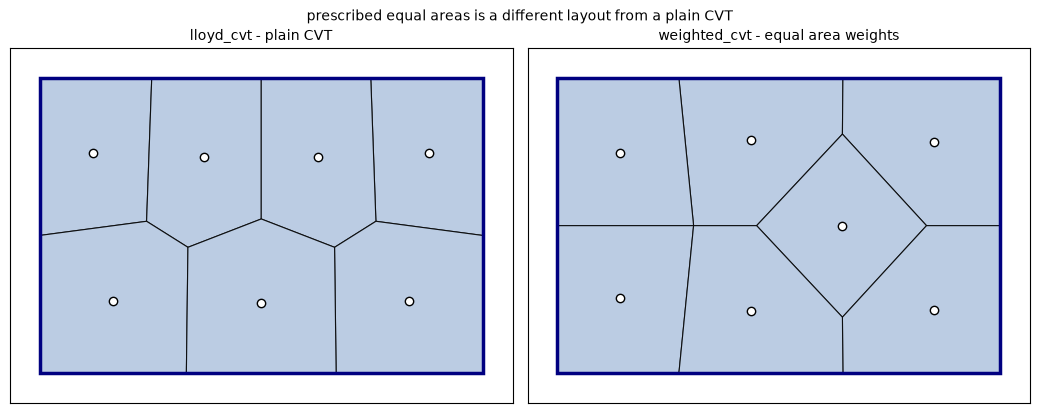

In [18]:
n = 7
plain_sites = lloyd_cvt(RECT, n)
equal = wcvt.weighted_cvt(RECT, [1.0] * n, seed=1)

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(10.5, 4.2))
panels = (
    (ax_a, plain_sites, 'lloyd_cvt - plain CVT'),
    (ax_b, equal.sites, 'weighted_cvt - equal area weights'),
)
poly = np.asarray(RECT, dtype=float)
for ax, sites, title in panels:
    for cell in wcvt.power_cells(RECT, sites):
        if len(cell) >= 3:
            ax.add_patch(MplPolygon(cell, closed=True, facecolor='lightsteelblue',
                                    edgecolor='black', linewidth=0.8, alpha=0.85))
    ax.add_patch(MplPolygon(poly, closed=True, fill=False,
                            edgecolor='navy', linewidth=2.5))
    xs = [p[0] for p in sites]
    ys = [p[1] for p in sites]
    ax.plot(xs, ys, marker='o', linestyle='none', color='white',
            markeredgecolor='black', markersize=6, zorder=6)
    ax.set_xlim(-0.2, 3.2)
    ax.set_ylim(-0.2, 2.2)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)
fig.suptitle('prescribed equal areas is a different layout from a plain CVT', fontsize=10)
fig.tight_layout()

problems = wcvt.validate_weighted(RECT, equal.sites, equal.weights, equal.targets)
print('validate the equal-weight run:', problems or 'clean')

## Interactive weight slider

Drag the last site's weight and watch its cell take over. Re-solving on every change is
fast enough at six sites to feel immediate.

In [ ]:
import ipywidgets as widgets


@widgets.interact(heavy=widgets.FloatSlider(value=3.0, min=0.1, max=12.0, step=0.1,
                                            description='weight 5'))
def _show(heavy):
    plot_case(RECT, [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, heavy], seed=1,
              title=f'weights 1/1/1/1/1/{heavy:.1f}')
    plt.show()

interactive(children=(FloatSlider(value=3.0, description='weight 5', max=12.0, min=0.1), Output()), _dom_class…

: 